<a href="https://colab.research.google.com/github/maryreginaf15/Programacao-Ia-Generativa/blob/main/opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---- Imagem Original com Marcação ----


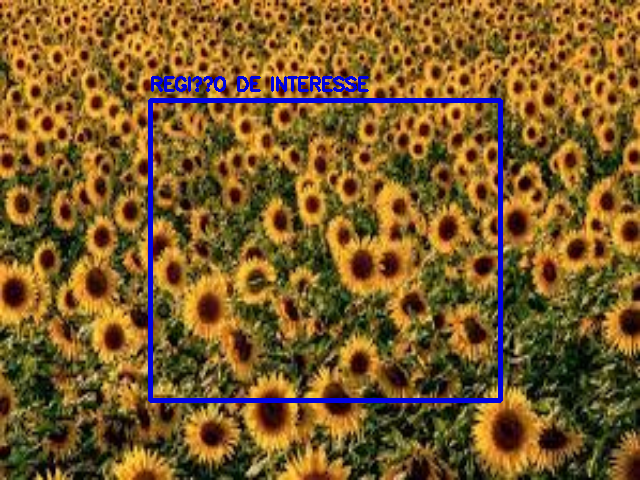


---- Imagem em Escala de Cinza ----


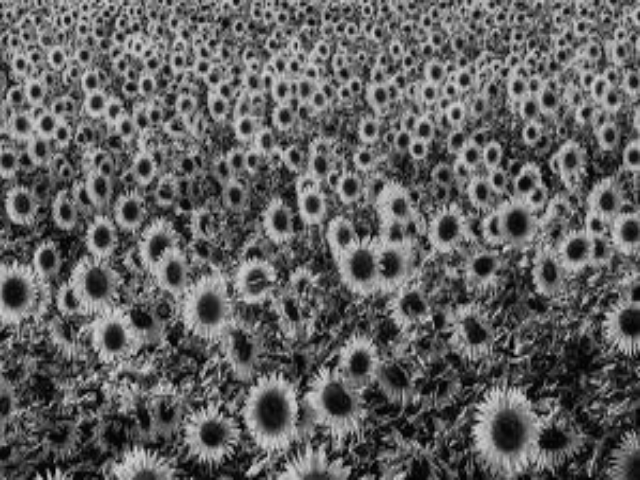

In [134]:
# leitura e Modificacao de imagem estetica

import cv2
from google.colab.patches import cv2_imshow

#1 Carregar a imagem
imagem = cv2.imread('cenario.jpg')

#2 Redimensionar para um tamanho padrão de exibição
imagem = cv2.resize(imagem, (640, 480))

#3 Converter para escala de cinza(simplificiacação matemática da matriz)
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

#4 Desenhar uma caixa de marcação manual em uma área da imagem
# Parâmetros: cv2.rectangle(imagem,(x_inicio, y_inicio), (x_fim, y_fim), (B, G, R),espessura)
cv2.rectangle(imagem,(150, 100),(500, 400), (225, 0, 0), 3)
cv2.putText(imagem, "REGIÃO DE INTERESSE", (150, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (225, 0 ,0), 2)

#5 Exibir os resultados na tela
print("---- Imagem Original com Marcação ----")
cv2_imshow(imagem)

print("\n---- Imagem em Escala de Cinza ----")
cv2_imshow(imagem_cinza)




In [ ]:

#Instalar as bibliotecas
!pip install easyocr opencv-python


[SISTEMA] Escaneando caracteres da placa...

[SUCESSO] texto estraído pela IA: RHA0AO1

 --- Recorte focada enviado para a IA


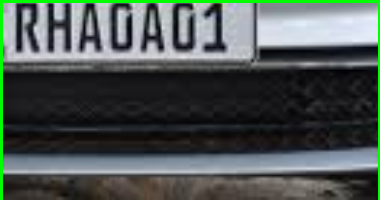


 --- Resultado do Sistema de  Monitoramento ----


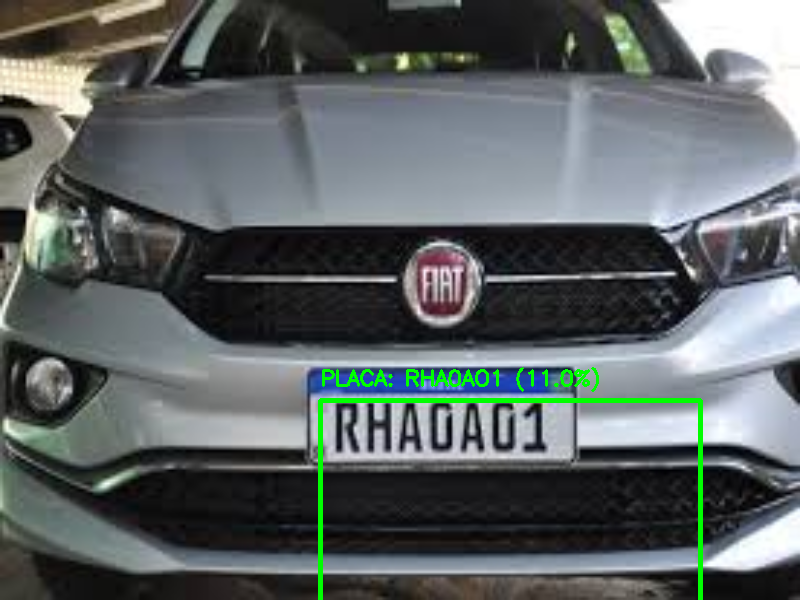

In [133]:
# Leitura automática de placas (OpenCV + OCR)

import cv2
import easyocr
from google.colab.patches import cv2_imshow

#1. Inicializar o leitor de OCR da IA para o idioma Português
leitor_ocr = easyocr.Reader(['pt'])

#2 Carregar a imagem do veiculo e redimensionar para manter um padrão
imagem_veiculo = cv2.imread('carro.jpg')
imagem_veiculo = cv2.resize(imagem_veiculo, (800, 600))

#3 Converter para escala de cinza para facilitar a leitura de caracteres pela IA
imagem_cinza = cv2.cvtColor(imagem_veiculo, cv2.COLOR_BGR2GRAY)

#4 Definir a Região de Interesse (ROI) da Placa
#Formato do recorte de matrizes no python: imagem[y_inicio: y_fim, x_inicio:x_fim]

# exemplo Coordenadas
x_ini, x_fim = 320, 700
y_ini, y_fim = 400, 700


placa_recortada_cinza = imagem_cinza[y_ini:y_fim, x_ini:x_fim]
placa_recortada_colorida = imagem_veiculo[y_ini:y_fim, x_ini:x_fim]


#5 Passar o recorte da IA  de OCR para extrair as letras/numeros
print("[SISTEMA] Escaneando caracteres da placa...")
resultados_ocr = leitor_ocr.readtext(placa_recortada_cinza)

# 6 Extrair o texto encontrado se a IA consegue ler algo
if len(resultados_ocr) > 0:
    # O resultado do EasyOCR vem no formato: [(coordenadas), "TEXTO DETECTADO", score_confiança]
    texto_placa = resultados_ocr[0][1].upper().replace(" ", "")
    confianca = resultados_ocr[0][2] * 100

    #7 Usar o OpenCV para desenhar o resultado de volta na imagem
    cv2.rectangle(imagem_veiculo, (x_ini, y_ini),(x_fim, y_fim), (0, 255, 0 ), 3)
    cv2.putText(imagem_veiculo,f"PLACA: {texto_placa} ({confianca:.1f}%)",
    (x_ini, y_ini - 15), cv2.FONT_HERSHEY_SIMPLEX,  0.7,  (0, 255, 0), 2)

    print(f"\n[SUCESSO] texto estraído pela IA: {texto_placa}")
else:

    print(f"\n[ALERTA] Não foi possivel identificar os caracteres. Ajuste o recorte da ROI")
    texto_placa = "NAO DETECTADA"

#8 Exibir o painel visual final para validação
print("\n --- Recorte focada enviado para a IA")
cv2_imshow(placa_recortada_colorida)

print("\n --- Resultado do Sistema de  Monitoramento ----")
cv2_imshow(imagem_veiculo)
